In [31]:
import pandas as pd
import torch

# split into train and test
from sklearn.model_selection import train_test_split

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


In [32]:
# load csv
# ./data/digit-recognizer/train.csv

df = pd.read_csv("./data/digit-recognizer/train.csv")

In [33]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
# assert labels are values from 0 to 9
assert df["label"].isin(range(10)).all()
# assert pixels are values from 0 to 255
for col in df.columns[1:]:
    assert df[col].isin(range(256)).all()

# change values to boolean true if pixel value is greater than 128, false otherwise
for col in df.columns[1:]:
    df[col] = df[col] > 64
    assert df[col].isin([True, False]).all()

# chang columns to boolean
for col in df.columns[1:]:
    df[col] = df[col].astype(bool)
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
41996,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
41997,7,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
41998,6,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop("label", axis=1), df["label"], test_size=0.2, random_state=42
)


# we will build a neural network with pytorch to get the probability of each class for each input,
# and then we will use the cross entropy loss to train the model. at the end we will use softmax
# to get the probabilities of each class for each input.


# create neural network model using torch
class DigitClassifier(torch.nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super(DigitClassifier, self).__init__()
        self.input_to_hidden_layer = torch.nn.Linear(input_size, hidden_size)
        self.hidden_to_hidden2_layer = torch.nn.Linear(hidden_size, hidden_size)
        self.hidden_to_output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.input_to_hidden_layer(x))
        # move data from hidden layer to hidden layer 2
        x = torch.relu(self.hidden_to_hidden2_layer(x))
        x = self.hidden_to_output_layer(x)
        return x


# input size is 784 (28x28 pixels), hidden size is 128, output size is 10 (digits from 0 to 9)
model = DigitClassifier(input_size=784, hidden_size=128, output_size=10)
# train the model
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# convert to torch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# train the model for 1000 epochs
for epoch in range(1000):
    # forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    # backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
# evaluate the model
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs.data, 1)
    accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)
    print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9580


In [36]:
# build sample submission file from the example submission file ./data/digit-recognizer/sample_submission.csv
sample_submission = pd.read_csv("./data/digit-recognizer/sample_submission.csv")
sample_submission.head()


,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [37]:
# ./data/digit-recognizer/test.csv
test_df = pd.read_csv("./data/digit-recognizer/test.csv")
test_df.head()

# make predictions for the test set
test_tensor = torch.tensor(test_df.values, dtype=torch.float32)
with torch.no_grad():
    outputs = model(test_tensor)
    _, predicted = torch.max(outputs.data, 1)
# create submission file
submission = pd.DataFrame(
    {"ImageId": range(1, len(predicted) + 1), "Label": predicted.numpy()}
)
submission.to_csv("./data/digit-recognizer/submission.csv", index=False)


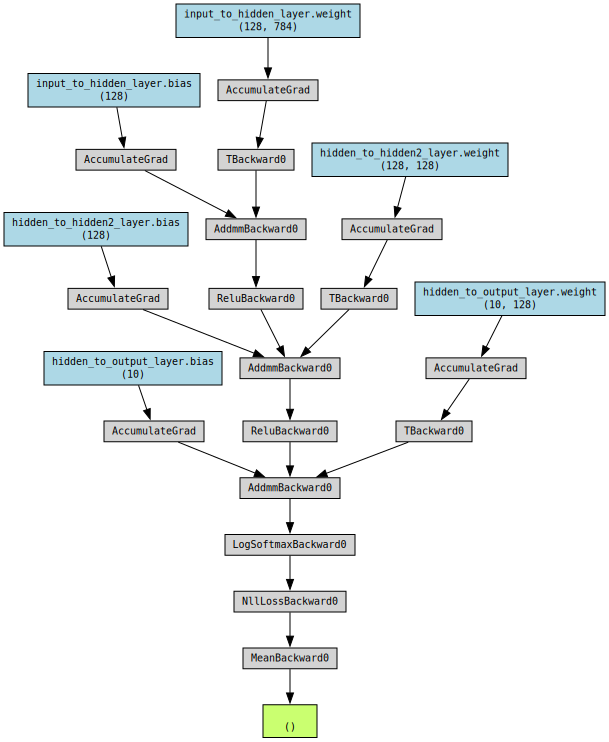

In [38]:
import torchviz

torchviz.make_dot(loss.mean(), params=dict(model.named_parameters()))


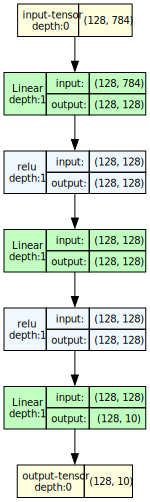

In [40]:
from torchview import draw_graph

model_graph = draw_graph(model, input_size=(128, 784), device=device)
model_graph.visual_graph

In [41]:
# dump model to file
torch.save(model.state_dict(), "./data/digit-recognizer/model.pth")

In [ ]:
# !kaggle competitions submit -c digit-recognizer -f ./data/digit-recognizer/submission.csv -m "Message"